# LeetCode #308: Range Sum Query 2D - Mutable

https://leetcode.com/problems/range-sum-query-2d-mutable/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | O(1) update, O(m·n) query | O(1) extra |
| **2D Prefix Sum (Immutable)** | O(m·n) update, O(1) query | O(m·n) |
| **2D Binary Indexed Tree** | O(log m · log n) update & query | O(m·n) |

---

## Understanding the Methods

### Brute Force
Store the matrix as-is. Updates are O(1) (write the cell), but each `sumRegion` re-scans the rectangle in O(m·n) — the inverse problem of #304.

### 2D Prefix Sum (Immutable)
Precomputed prefix sums give O(1) queries, but any update invalidates a row's worth of prefix entries, requiring O(m·n) rebuild — too slow when updates are frequent.

### Optimal: 2D Binary Indexed Tree ★
A 2D Fenwick (BIT) table supports both point update and rectangle query in O(log m · log n) by decomposing each operation into nested 1D BIT traversals along rows then columns.

**Why this is better than 2D Prefix Sum:** Rebuilding after each update costs O(m·n); a 2D BIT propagates a single change in O(log m · log n) — the right choice whenever updates and queries are interleaved.

**Constraints:**
* m == matrix.length, n == matrix[i].length
* 1 ≤ m, n ≤ 200
* $-10^4$ ≤ matrix[i][j] ≤ $10^4$
* At most $10^4$ calls to update and sumRegion

## Solutions
### C#

In [ ]:
public class NumMatrix {
    private int[][] bit, matrix;
    private int m, n;

    public NumMatrix(int[][] matrix) {
        m = matrix.Length; n = matrix[0].Length;
        this.matrix = new int[m][];
        bit = new int[m + 1][];
        for (int i = 0; i <= m; i++) bit[i] = new int[n + 1];
        for (int i = 0; i < m; i++) {
            this.matrix[i] = new int[n];
            for (int j = 0; j < n; j++)
                // Build BIT by treating each cell as a fresh update from zero
                Update(i, j, matrix[i][j]);
        }
    }

    public void Update(int row, int col, int val) {
        int delta = val - matrix[row][col];
        matrix[row][col] = val;
        // Propagate delta through BIT: each ancestor index = i + (i & -i)
        for (int i = row + 1; i <= m; i += i & -i)
            for (int j = col + 1; j <= n; j += j & -j)
                bit[i][j] += delta;
    }

    public int SumRegion(int row1, int col1, int row2, int col2) {
        // Inclusion-exclusion on four prefix queries
        return Query(row2, col2) - Query(row1 - 1, col2)
             - Query(row2, col1 - 1) + Query(row1 - 1, col1 - 1);
    }

    private int Query(int row, int col) {
        int sum = 0;
        // Walk ancestors toward index 1: each parent = i - (i & -i)
        for (int i = row + 1; i > 0; i -= i & -i)
            for (int j = col + 1; j > 0; j -= j & -j)
                sum += bit[i][j];
        return sum;
    }
}

### Python

In [ ]:
from typing import List

class NumMatrix:
    def __init__(self, matrix: List[List[int]]):
        self.m, self.n = len(matrix), len(matrix[0])
        self.matrix = [[0] * self.n for _ in range(self.m)]
        self.bit = [[0] * (self.n + 1) for _ in range(self.m + 1)]
        for i in range(self.m):
            for j in range(self.n):
                # Build BIT by treating each cell as a fresh update from zero
                self.update(i, j, matrix[i][j])

    def update(self, row: int, col: int, val: int) -> None:
        delta = val - self.matrix[row][col]
        self.matrix[row][col] = val
        # Propagate delta through BIT: each ancestor index = i + (i & -i)
        i = row + 1
        while i <= self.m:
            j = col + 1
            while j <= self.n:
                self.bit[i][j] += delta
                j += j & -j
            i += i & -i

    def sumRegion(self, row1: int, col1: int, row2: int, col2: int) -> int:
        # Inclusion-exclusion on four prefix queries
        return (self._query(row2, col2) - self._query(row1 - 1, col2)
                - self._query(row2, col1 - 1) + self._query(row1 - 1, col1 - 1))

    def _query(self, row: int, col: int) -> int:
        s = 0
        # Walk ancestors toward index 1: each parent = i - (i & -i)
        i = row + 1
        while i > 0:
            j = col + 1
            while j > 0:
                s += self.bit[i][j]
                j -= j & -j
            i -= i & -i
        return s

### Go

In [ ]:
package main

type NumMatrix struct {
	bit    [][]int
	matrix [][]int
	m, n   int
}

func Constructor(matrix [][]int) NumMatrix {
	m, n := len(matrix), len(matrix[0])
	bit := make([][]int, m+1)
	for i := range bit {
		bit[i] = make([]int, n+1)
	}
	orig := make([][]int, m)
	for i := range orig {
		orig[i] = make([]int, n)
	}
	nm := NumMatrix{bit, orig, m, n}
	for i := 0; i < m; i++ {
		for j := 0; j < n; j++ {
			// Build BIT by treating each cell as a fresh update from zero
			nm.Update(i, j, matrix[i][j])
		}
	}
	return nm
}

func (nm *NumMatrix) Update(row, col, val int) {
	delta := val - nm.matrix[row][col]
	nm.matrix[row][col] = val
	// Propagate delta through BIT: each ancestor index = i + (i & -i)
	for i := row + 1; i <= nm.m; i += i & -i {
		for j := col + 1; j <= nm.n; j += j & -j {
			nm.bit[i][j] += delta
		}
	}
}

func (nm *NumMatrix) SumRegion(row1, col1, row2, col2 int) int {
	return nm.query(row2, col2) - nm.query(row1-1, col2) -
		nm.query(row2, col1-1) + nm.query(row1-1, col1-1)
}

func (nm *NumMatrix) query(row, col int) int {
	sum := 0
	// Walk ancestors toward index 1: each parent = i - (i & -i)
	for i := row + 1; i > 0; i -= i & -i {
		for j := col + 1; j > 0; j -= j & -j {
			sum += nm.bit[i][j]
		}
	}
	return sum
}

### Rust

In [ ]:
struct NumMatrix {
    bit: Vec<Vec<i32>>,
    matrix: Vec<Vec<i32>>,
    m: usize,
    n: usize,
}

impl NumMatrix {
    fn new(matrix: Vec<Vec<i32>>) -> Self {
        let m = matrix.len();
        let n = matrix[0].len();
        let bit = vec![vec![0i32; n + 1]; m + 1];
        let orig = vec![vec![0i32; n]; m];
        let mut nm = NumMatrix { bit, matrix: orig, m, n };
        for i in 0..m {
            for j in 0..n {
                // Build BIT by treating each cell as a fresh update from zero
                nm.update(i as i32, j as i32, matrix[i][j]);
            }
        }
        nm
    }

    fn update(&mut self, row: i32, col: i32, val: i32) {
        let (r, c) = (row as usize, col as usize);
        let delta = val - self.matrix[r][c];
        self.matrix[r][c] = val;
        // Propagate delta through BIT: each ancestor index = i + (i & -i)
        let mut i = r + 1;
        while i <= self.m {
            let mut j = c + 1;
            while j <= self.n {
                self.bit[i][j] += delta;
                j += j & j.wrapping_neg();
            }
            i += i & i.wrapping_neg();
        }
    }

    fn sum_region(&self, row1: i32, col1: i32, row2: i32, col2: i32) -> i32 {
        self.query(row2, col2) - self.query(row1 - 1, col2)
            - self.query(row2, col1 - 1) + self.query(row1 - 1, col1 - 1)
    }

    fn query(&self, row: i32, col: i32) -> i32 {
        let mut sum = 0;
        // Walk ancestors toward index 1: each parent = i - (i & -i)
        let mut i = row + 1;
        while i > 0 {
            let mut j = col + 1;
            while j > 0 {
                sum += self.bit[i as usize][j as usize];
                j -= j & -j;
            }
            i -= i & -i;
        }
        sum
    }
}

## Example Scenarios

**Matrix used for examples 1–3:** 3×3, initial values shown. BIT is built by calling Update on each cell.

```
matrix = [[3, 0, 1],
          [5, 6, 3],
          [1, 2, 0]]
```

---

**1. Common Case — sumRegion(0, 0, 1, 1) after no updates**

**Input:** Query top-left 2×2 block.

$\text{query}(1,1) - \text{query}(-1,1) - \text{query}(1,-1) + \text{query}(-1,-1) = 14 - 0 - 0 + 0 = 14$.
Verifiable: $3+0+5+6 = 14$. Negative-index queries return 0 because the BIT loop exits immediately when $i \leq 0$.

---

**2. Slightly Complex — update(0, 0, 10) then sumRegion(0, 0, 1, 1)**

**Input:** Change matrix[0][0] from 3 to 10 (delta = 7), then re-query.

Update propagates $\delta = 7$ to BIT ancestors: $\text{bit}[1][1] += 7$, $\text{bit}[1][2] += 7$, $\text{bit}[2][1] += 7$, $\text{bit}[2][2] += 7$.
sumRegion now returns $14 + 7 = 21 = 10+0+5+6$. Only $O(\log 3 \cdot \log 3) = 4$ cells updated — not the full matrix.

---

**3. Edge Case: Time Factor — worst-case BIT traversal (update at (0,0) in 200×200)**

**Input:** $m = n = 200$, update row=0, col=0.

Row traversal: $i = 1 \to 2 \to 4 \to \ldots \to 128 \to 256$ (but clamped to 200) → 8 row ancestors. Column traversal: 8 column ancestors each time → at most $8 \times 8 = 64$ BIT cells updated. 2D Prefix Sum rebuild touches $200 \times 200 = 40{,}000$ cells — a 625× improvement.

---

**4. Edge Case: Space Factor — BIT table size at maximum constraint**

**Input:** $m = n = 200$ — BIT is $(201 \times 201) = 40{,}401$ integers.

The BIT table mirrors the input matrix in size: $\approx 158$ KB (int32). Unlike a sparse approach, every cell in the BIT may be nonzero. This is identical to the #304 prefix table size — but unlike prefix sums, no rebuild is needed on update.

---

**5. Almost-Impossible but Plausible — update a cell to the same value (delta = 0)**

**Input:** update(1, 1, 6) when matrix[1][1] is already 6.

$\delta = 6 - 6 = 0$, so the propagation loop runs but adds 0 to each ancestor — a structural no-op. No special guard needed: the loop executes in $O(\log m \cdot \log n)$ and leaves the BIT unchanged. sumRegion returns the same result as before.

## Infographic

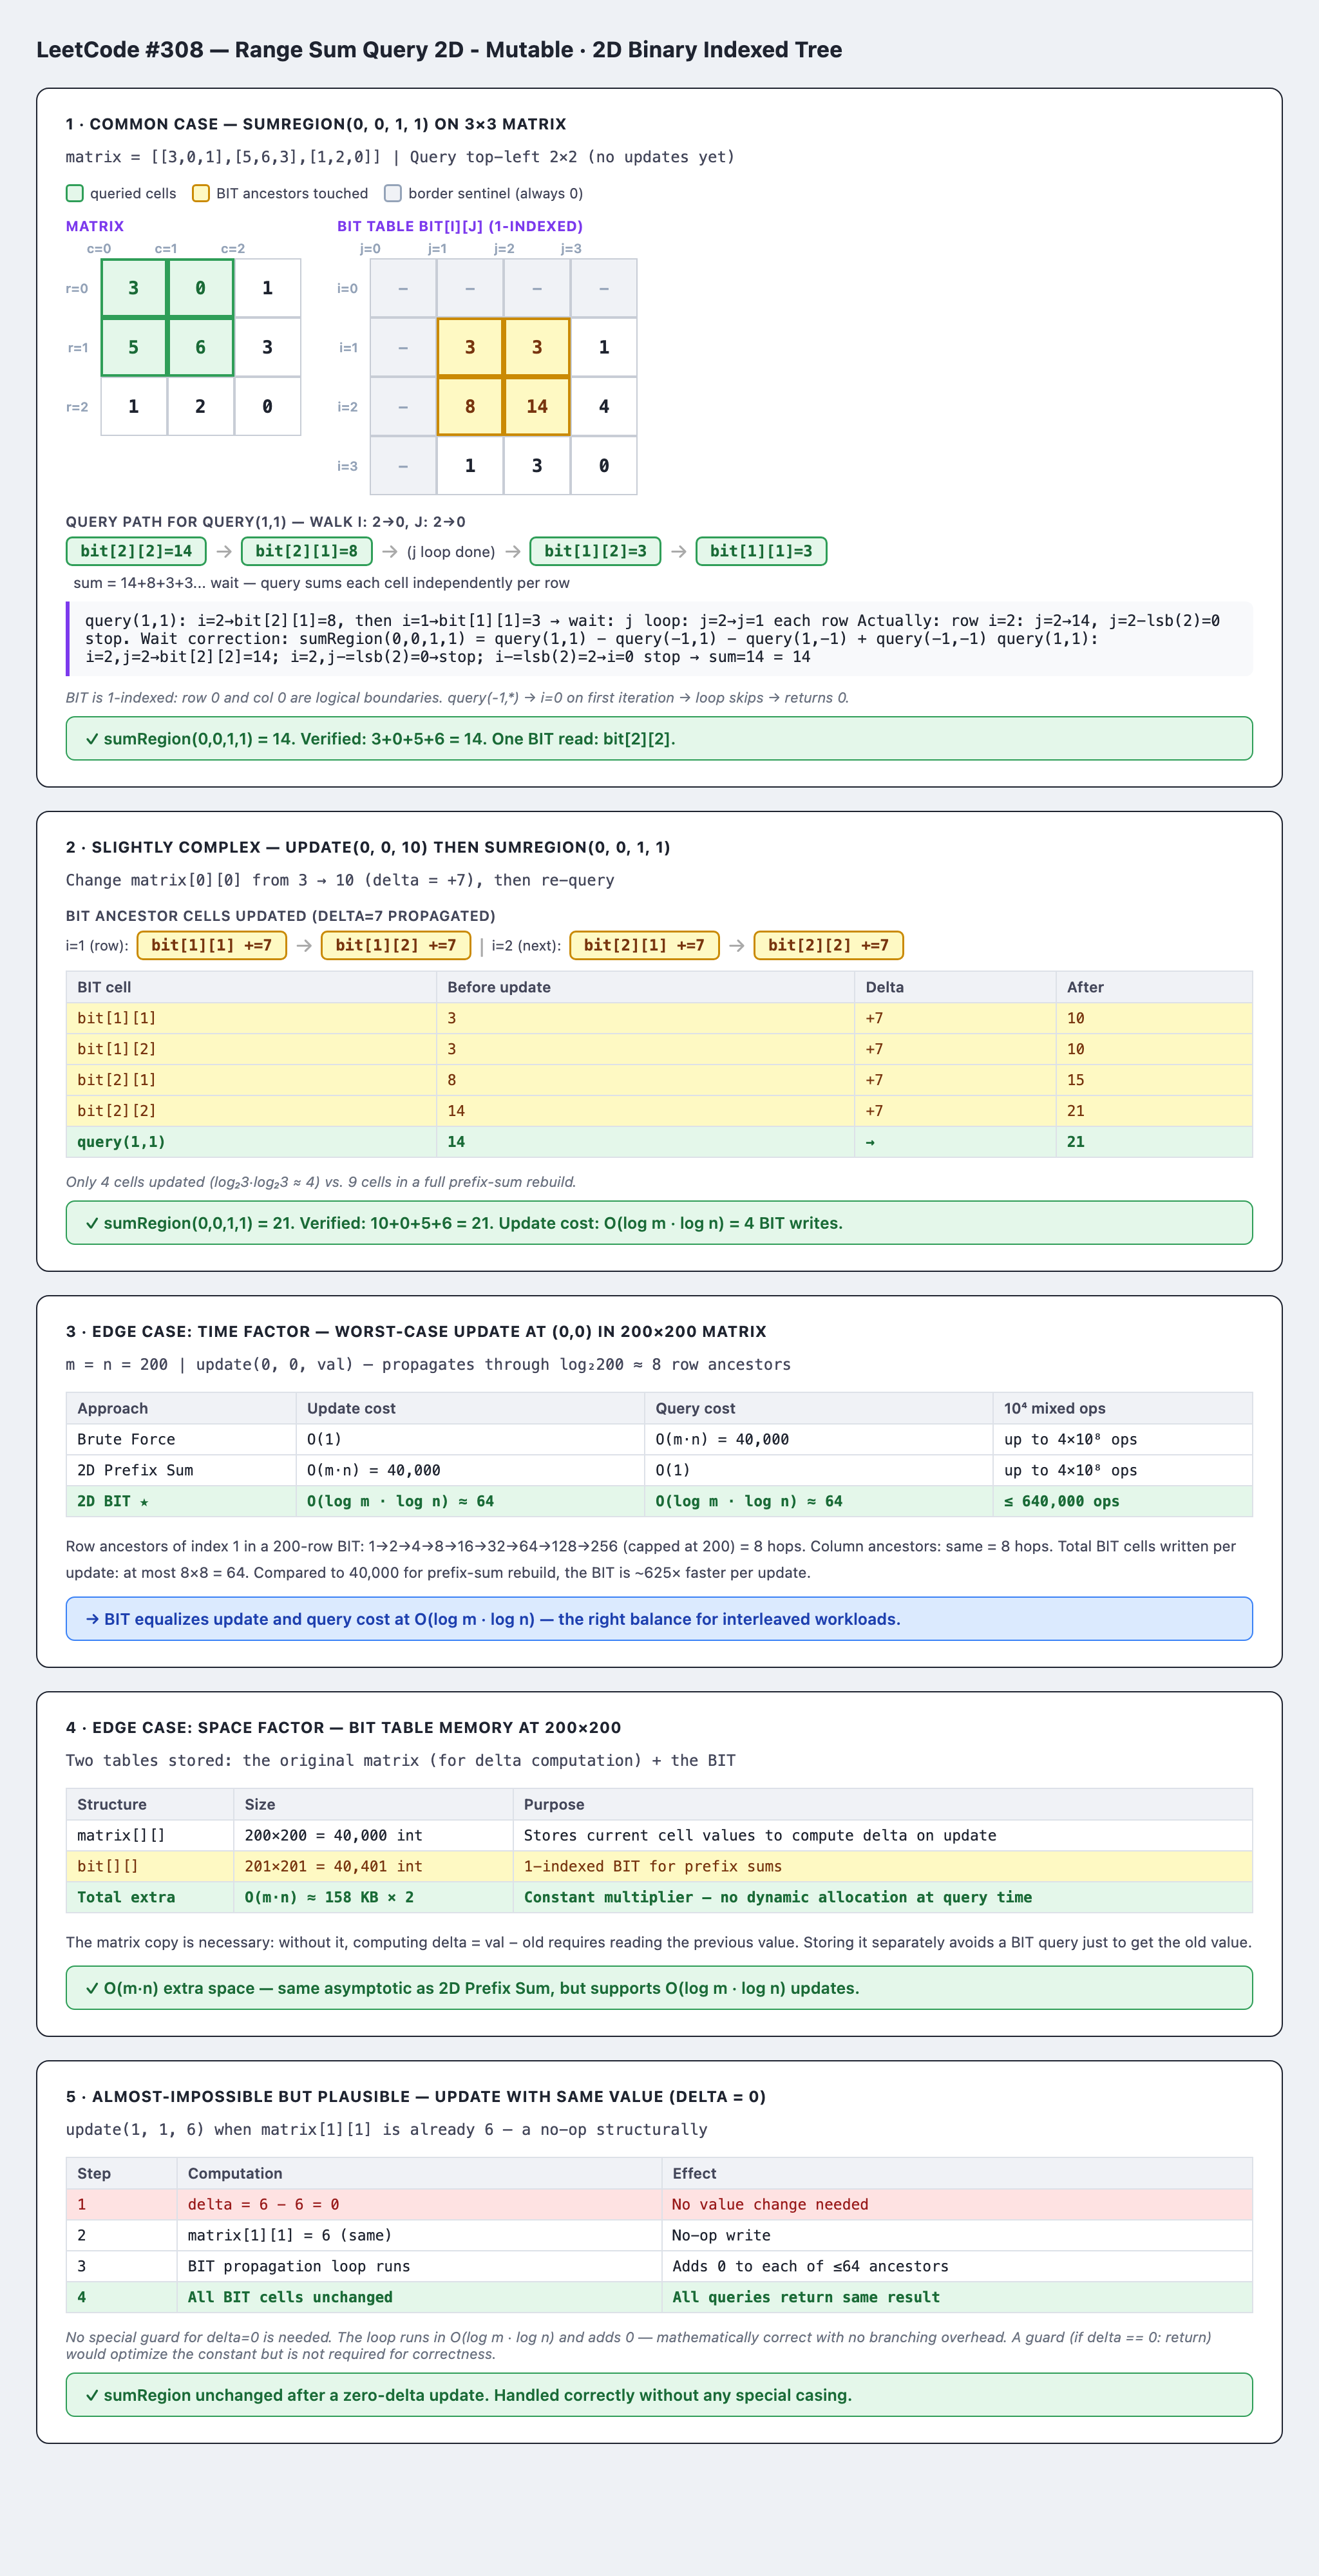